# 模型窃取攻击 (Model Extraction Attack)

本 Notebook 模拟**模型窃取攻击**：攻击者仅通过查询目标模型的预测 API，收集输入-软标签对，训练出一个功能相近的**替代模型（Surrogate Model）**。

- 核心思想：Tramèr et al. (2016) 表明，只要攻击者能够大量查询目标模型并获得概率输出，就可以通过知识蒸馏的方式复现模型行为。
- 参考：CAISP《模块二 技术基础篇》第 136-139 页。


In [1]:
# 导入依赖库
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
# 加载完整 CIFAR-10 数据集作为目标模型的训练/测试数据
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

CIFAR10_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
BATCH_SIZE = 64
EPOCHS_TARGET = 15

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {len(train_set)}, Test: {len(test_set)}")


Train: 50000, Test: 10000


In [3]:
# 定义目标模型与替代模型使用的 CNN 架构
class SimpleCNN(nn.Module):
    '''10 类 CIFAR-10 分类器'''
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [4]:
# 训练与评估工具函数

def train_model(model, loader, epochs=15, lr=0.001):
    '''使用标准交叉熵训练模型'''
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        avg_loss = running_loss / len(loader.dataset)
        print(f"Epoch {epoch+1}/{epochs}, loss: {avg_loss:.4f}")
    return model


def evaluate_accuracy(model, loader):
    '''计算模型在数据集上的分类准确率'''
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total if total > 0 else 0.0


def evaluate_agreement(target, surrogate, loader):
    '''计算目标模型与替代模型的一致率（预测标签相同所占比例）'''
    target.eval()
    surrogate.eval()
    correct_t, correct_s, total, agree = 0, 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred_t = target(x).argmax(dim=1)
            pred_s = surrogate(x).argmax(dim=1)
            correct_t += (pred_t == y).sum().item()
            correct_s += (pred_s == y).sum().item()
            agree += (pred_t == pred_s).sum().item()
            total += y.size(0)
    return correct_t / total, correct_s / total, agree / total


In [5]:
# 训练目标模型（模拟部署在 API 后的受害者模型）
target_model = SimpleCNN(num_classes=10).to(device)
target_model = train_model(target_model, train_loader, epochs=EPOCHS_TARGET)

target_test_acc = evaluate_accuracy(target_model, test_loader)
print(f"Target model test accuracy: {target_test_acc:.4f}")


Epoch 1/15, loss: 1.5767
Epoch 2/15, loss: 1.2618
Epoch 3/15, loss: 1.1148
Epoch 4/15, loss: 1.0161
Epoch 5/15, loss: 0.9385
Epoch 6/15, loss: 0.8784
Epoch 7/15, loss: 0.8267
Epoch 8/15, loss: 0.7810
Epoch 9/15, loss: 0.7477
Epoch 10/15, loss: 0.7138
Epoch 11/15, loss: 0.6756
Epoch 12/15, loss: 0.6448
Epoch 13/15, loss: 0.6146
Epoch 14/15, loss: 0.5861
Epoch 15/15, loss: 0.5566
Target model test accuracy: 0.6935


## 模型窃取流程

攻击者并不拥有目标模型的参数或训练数据，流程如下：

```text
[Attacker] 生成合成查询 / 使用公开数据集
         |
         v
[Target Model API] 返回软标签概率分布 p(y|x)
         |
         v
[Attacker] 使用 (x, p(y|x)) 训练替代模型
         |
         v
[Surrogate Model] 功能逼近目标模型
```


In [6]:
# 攻击者：生成查询数据并查询目标模型，获得软标签

def generate_queries(num_queries, mode='noise'):
    '''生成攻击者使用的查询数据：随机噪声或公开数据集（CIFAR-10 测试集）'''
    if mode == 'noise':
        # 随机噪声图像，攻击者完全不需要真实训练数据
        return torch.rand(num_queries, 3, 32, 32)
    elif mode == 'public':
        # 使用公开测试集作为替代训练数据
        indices = np.random.choice(len(test_set), num_queries, replace=False)
        subset = Subset(test_set, indices)
        loader = DataLoader(subset, batch_size=num_queries, shuffle=False)
        x, _ = next(iter(loader))
        return x
    else:
        raise ValueError("mode should be 'noise' or 'public'")


def query_target(model, queries):
    '''查询目标模型，返回软标签概率'''
    model.eval()
    with torch.no_grad():
        queries = queries.to(device)
        return F.softmax(model(queries), dim=1).cpu()


def train_surrogate(target_model, query_x, query_y, epochs=20, lr=0.001):
    '''通过知识蒸馏训练替代模型：使替代模型输出逼近目标模型的软标签'''
    surrogate = SimpleCNN(num_classes=10).to(device)
    optimizer = optim.Adam(surrogate.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(query_x, query_y)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for epoch in range(epochs):
        surrogate.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = surrogate(xb)
            log_probs = F.log_softmax(logits, dim=1)
            # 软标签交叉熵：最小化 -Σ p_target * log(p_surrogate)
            loss = -(yb * log_probs).sum(dim=1).mean()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        print(f"Surrogate epoch {epoch+1}/{epochs}, loss: {epoch_loss/len(loader.dataset):.4f}")
    return surrogate

# 使用 10000 条随机噪声查询进行模型窃取
NUM_QUERIES = 10000
query_x = generate_queries(NUM_QUERIES, mode='noise')
query_y = query_target(target_model, query_x)
print(f"Query shape: {query_x.shape}, soft label shape: {query_y.shape}")


Query shape: torch.Size([10000, 3, 32, 32]), soft label shape: torch.Size([10000, 10])


In [7]:
# 训练替代模型并评估其与目标模型的相似度
surrogate_model = train_surrogate(target_model, query_x, query_y, epochs=20)

target_acc, surrogate_acc, agreement = evaluate_agreement(target_model, surrogate_model, test_loader)
print(f"Target accuracy:    {target_acc:.4f}")
print(f"Surrogate accuracy: {surrogate_acc:.4f}")
print(f"Agreement rate:     {agreement:.4f}")


Surrogate epoch 1/20, loss: 0.9156
Surrogate epoch 2/20, loss: 0.8848
Surrogate epoch 3/20, loss: 0.8826
Surrogate epoch 4/20, loss: 0.8838
Surrogate epoch 5/20, loss: 0.8776
Surrogate epoch 6/20, loss: 0.8696
Surrogate epoch 7/20, loss: 0.8595
Surrogate epoch 8/20, loss: 0.8528
Surrogate epoch 9/20, loss: 0.8409
Surrogate epoch 10/20, loss: 0.8297
Surrogate epoch 11/20, loss: 0.8162
Surrogate epoch 12/20, loss: 0.8066
Surrogate epoch 13/20, loss: 0.8006
Surrogate epoch 14/20, loss: 0.7877
Surrogate epoch 15/20, loss: 0.7784
Surrogate epoch 16/20, loss: 0.7692
Surrogate epoch 17/20, loss: 0.7619
Surrogate epoch 18/20, loss: 0.7550
Surrogate epoch 19/20, loss: 0.7488
Surrogate epoch 20/20, loss: 0.7413
Target accuracy:    0.6935
Surrogate accuracy: 0.1101
Agreement rate:     0.1235


In [8]:
# 探究查询预算对窃取效果的影响：查询越多，替代模型越逼近目标模型
query_budgets = [500, 1000, 2000, 5000, 10000]
target_accs = []
surrogate_accs = []
agreements = []

for budget in query_budgets:
    qx = generate_queries(budget, mode='noise')
    qy = query_target(target_model, qx)
    sur = train_surrogate(target_model, qx, qy, epochs=15)
    tacc, sacc, agr = evaluate_agreement(target_model, sur, test_loader)
    target_accs.append(tacc)
    surrogate_accs.append(sacc)
    agreements.append(agr)
    print(f"Budget={budget:5d}: target={tacc:.4f}, surrogate={sacc:.4f}, agreement={agr:.4f}")


Surrogate epoch 1/15, loss: 1.3684
Surrogate epoch 2/15, loss: 0.9557
Surrogate epoch 3/15, loss: 0.8844
Surrogate epoch 4/15, loss: 0.8778
Surrogate epoch 5/15, loss: 0.8731
Surrogate epoch 6/15, loss: 0.8644
Surrogate epoch 7/15, loss: 0.8599
Surrogate epoch 8/15, loss: 0.8593
Surrogate epoch 9/15, loss: 0.8625
Surrogate epoch 10/15, loss: 0.8584
Surrogate epoch 11/15, loss: 0.8607
Surrogate epoch 12/15, loss: 0.8592
Surrogate epoch 13/15, loss: 0.8567
Surrogate epoch 14/15, loss: 0.8568
Surrogate epoch 15/15, loss: 0.8569
Budget=  500: target=0.6935, surrogate=0.1000, agreement=0.1119
Surrogate epoch 1/15, loss: 1.2615
Surrogate epoch 2/15, loss: 0.8688
Surrogate epoch 3/15, loss: 0.8488
Surrogate epoch 4/15, loss: 0.8425
Surrogate epoch 5/15, loss: 0.8428
Surrogate epoch 6/15, loss: 0.8375
Surrogate epoch 7/15, loss: 0.8379
Surrogate epoch 8/15, loss: 0.8375
Surrogate epoch 9/15, loss: 0.8356
Surrogate epoch 10/15, loss: 0.8370
Surrogate epoch 11/15, loss: 0.8366
Surrogate epoch 12

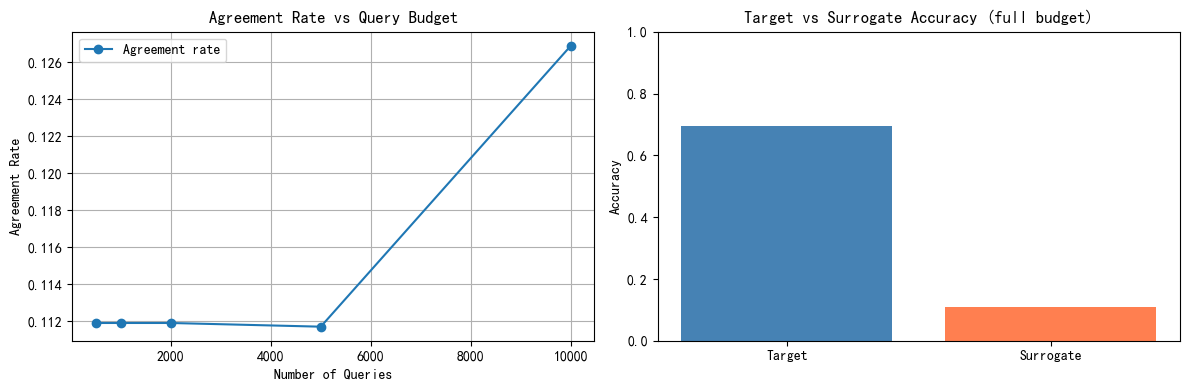

In [9]:
# 可视化：一致率随查询数量变化，以及目标/替代模型准确率对比

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(query_budgets, agreements, marker='o', label='Agreement rate')
plt.xlabel('Number of Queries')
plt.ylabel('Agreement Rate')
plt.title('Agreement Rate vs Query Budget')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
x = np.arange(2)
labels = ['Target', 'Surrogate']
values = [target_acc, surrogate_acc]
plt.bar(x, values, color=['steelblue', 'coral'])
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('Target vs Surrogate Accuracy (full budget)')
plt.ylim(0, 1.0)

plt.tight_layout()
plt.show()


**可视化：查询量 vs 替代模型一致性**

查询预算越大，替代模型通过蒸馏越能逼近目标模型，二者预测标签的一致率也随之上升。

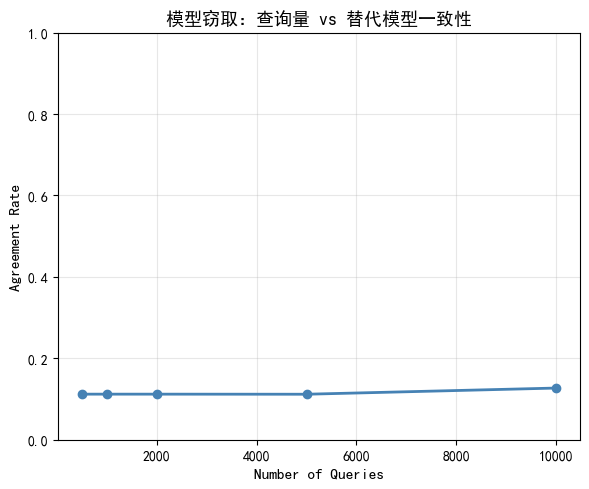

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(query_budgets, agreements, marker='o', color='steelblue',
         linewidth=2, markersize=6)
plt.xlabel('Number of Queries', fontsize=11)
plt.ylabel('Agreement Rate', fontsize=11)
plt.title('模型窃取：查询量 vs 替代模型一致性', fontsize=13)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 小结与防御思路

- **攻击原理**：模型窃取攻击通过大量查询目标模型并将预测概率作为软标签，训练替代模型来逼近目标模型行为。查询数量越多、目标模型越“软”（返回完整概率），窃取效果越好。
- **防御方法**：
  1. **限制查询速率/总量**：对每个用户/IP 设置查询配额，降低攻击者采集数据的能力。
  2. **输出压缩/取整**：只返回 top-k 标签，或将概率四舍五入到较低精度，减少信息泄露。
  3. **异常查询检测**：检测异常分布或高频查询行为，触发验证/封禁。
